In [112]:
# ── SETUP
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path
import os
from pathlib import Path
import random
random.seed(42)

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
      class_dir = DATA_DIR / label
      files = list(class_dir.glob("*.jpg"))                                                                            
      img_path = random.choice(files)
      return Image.open(img_path).convert("RGB"), img_path.name

img, name = load_sample_image("mountain")
print(f"Loaded: {name}, size: {img.size}")
os.makedirs("outputs", exist_ok=True)
  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")


Loaded: 24204.jpg, size: (150, 150)
Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


## PyTorch Tensors
  ### Q1 — Create tensors and inspect their properties

In [113]:
  a = torch.tensor([[1.0, 2.0, 3.0],
                    [4.0, 5.0, 6.0]])
  b = torch.zeros(2, 3)
  c = torch.ones(4)

  for name, t in [("a", a), ("b", b), ("c", c)]:
      print(f"Tensor {name}:")
      print(f"  value:  {t}")
      print(f"  shape:  {t.shape}")
      print(f"  dtype:  {t.dtype}")
      print(f"  device: {t.device}\n")

  # These tensors live on CPU by default.
  # In a training loop, model weights live on GPU after .to(device).
  # If your input tensor is still on CPU, PyTorch will throw a device mismatch 
  #error
  # Every tensor involved in a computation must be on the same device.

Tensor a:
  value:  tensor([[1., 2., 3.],
        [4., 5., 6.]])
  shape:  torch.Size([2, 3])
  dtype:  torch.float32
  device: cpu

Tensor b:
  value:  tensor([[0., 0., 0.],
        [0., 0., 0.]])
  shape:  torch.Size([2, 3])
  dtype:  torch.float32
  device: cpu

Tensor c:
  value:  tensor([1., 1., 1., 1.])
  shape:  torch.Size([4])
  dtype:  torch.float32
  device: cpu



### Q2 — Element-wise operations and argmax

In [114]:
 x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])
  
print("Square root:      ", torch.sqrt(x))
print("Sum:              ", x.sum())
print("Mean:             ", x.mean())
print("Index of max:     ", x.argmax())
  
  # .argmax() returns the INDEX of the highest value, not the value itself.
  # In a classifier outputting 1,000 scores, .argmax() gives you the position
  # of the winning class — you then look that index up in your class name list
  # to get the human-readable label. This is the last step of every inference 
  #call.

Square root:       tensor([1., 2., 3., 4., 5.])
Sum:               tensor(55.)
Mean:              tensor(11.)
Index of max:      tensor(4)


### Q3 — Moving tensors between CPU and GPU

In [115]:
  a_gpu  = a.to(device)
  print(f"a_gpu device: {a_gpu.device}")
  
  a_back  = a_gpu.cpu()
  a_numpy = a_back.numpy()
  print(f"numpy type:   {type(a_numpy)}")
  print(f"numpy values:\n{a_numpy}")
  
  # PyTorch requires .cpu() before .numpy() because NumPy arrays can only
  # exist in CPU memory — NumPy has no concept of GPU memory.
  # This tells you that GPU tensors and NumPy arrays live in completely
  # different memory spaces. Moving between them requires an explicit transfer.

a_gpu device: cuda:0
numpy type:   <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


### Q4 — Shape manipulation

In [116]:
t = torch.arange(24).float()
  
t_4x6   = t.reshape(4, 6)
print("Reshaped to (4, 6):    ", t_4x6.shape)
  
t_2x3x4 = t.reshape(2, 3, 4)
print("Reshaped to (2, 3, 4): ", t_2x3x4.shape)
  
t_with_batch = t_4x6.unsqueeze(0)
print("After unsqueeze(0):    ", t_with_batch.shape)
  
  # A single image tensor has shape (channels, height, width) — e.g. (3, 224, 224).
  # Neural networks expect batches: (batch_size, channels, height, width).
  # When processing one image at a time, .unsqueeze(0) inserts the batch dimension
  # at position 0, turning (3, 224, 224) into (1, 3, 224, 224).
  # Without it, the model throws a shape error — it always expects a batch axis.

Reshaped to (4, 6):     torch.Size([4, 6])
Reshaped to (2, 3, 4):  torch.Size([2, 3, 4])
After unsqueeze(0):     torch.Size([1, 4, 6])


### Q5 — Matrix multiplication: NumPy vs PyTorch

In [117]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])
t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)
  
np_result = np.matmul(np_a, np_b)
pt_result = torch.matmul(t_a, t_b)
  
print("NumPy result:\n",   np_result)
print("PyTorch result:\n", pt_result.numpy())
print("Results match:     ", np.allclose(np_result, pt_result.numpy()))
  
  # Matrix multiplication is the core operation in every neural network layer.
  # When data passes through a layer, each neuron computes a weighted sum of its inputs
  # — that's a dot product. Doing this for all neurons at once is matrix multiplication.
  # Every forward pass through a network is a chain of matrix multiplications,
  # which is exactly why GPUs — built for parallel matrix math — dominate this field.


NumPy result:
 [[19. 22.]
 [43. 50.]]
PyTorch result:
 [[19. 22.]
 [43. 50.]]
Results match:      True


## Pretrained Models
### Model Q1 — Load ResNet18 and count parameters

In [118]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

  # ResNet18 has ~11 million parameters trained on 1.2M ImageNet images over days of GPU compute.
  # Downloading pretrained weights takes seconds and gives you all of that for free.
  # This is why pretrained models are the default starting point in production —
  # training from scratch requires data and compute budgets most projects don't have.

Total parameters:     11,689,512
Trainable parameters: 11,689,512


### Model Q2 — Print architecture and identify layers

In [119]:
print(model)

  # The final layer is named 'fc' (fully connected) with output size 1000 —
  # one score per ImageNet category.
  # Layers named layer1 through layer4 are the 'deep' part — the feature extractor.
  # 'Deep' means many sequential layers of transformations. Each layer builds on the
  # previous one: layer1 detects edges, layer2 detects textures, layer3 detects shapes,
  # layer4 detects high-level objects. Depth = abstraction.

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Model Q3 — Move to device and set eval mode

In [120]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

  # .to(device) moves all 11M parameter tensors to the GPU.
  # Every input tensor you feed the model must also be on the same device —
  # PyTorch will throw a device mismatch error otherwise.
  #
  # model.eval() changes two layer behaviors:
  # 1. Dropout: randomly zeros neurons during training to prevent overfitting.
  #    In eval mode, dropout is disabled — all neurons are active for stable predictions.
  # 2. BatchNorm: normalizes activations using batch statistics during training.
  #    In eval mode, it uses running statistics collected during training instead.
  #    Forgetting .eval() before inference is a common bug — predictions will be
  #    slightly wrong and non-deterministic.

Model ready for inference.


### Model Q4 — Inspect the preprocessing pipeline

In [121]:
preprocess = weights.transforms()
print(preprocess)
  
  # The transform chain does three things:
  # 1. Resize + CenterCrop to 224×224: the model's convolutional layers expect a fixed
  #    input size. Every image must be the same shape before it enters the network.
  #
  # 2. ToTensor(): converts pixel values from integers [0, 255] to floats [0.0, 1.0].
  #    Neural networks train poorly on large integer values — small floats are more
  #    numerically stable during gradient updates.
  #
  # 3. Normalize with ImageNet mean and std: subtracts [0.485, 0.456, 0.406] from
  #    each RGB channel and divides by [0.229, 0.224, 0.225]. These are the exact
  #    per-channel statistics of the ImageNet training set.
  #    Why these specific values and not 0.5? Because the model was trained with
  #    these values — its weights learned to expect this exact input distribution.
  #    Using different normalization shifts the distribution the model sees,
  #    silently degrading predictions without any error message.

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## Running Inference
# Setup — image loader and ImageNet labels

### Inference Q1 — get_top5_predictions function

In [122]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
      input_tensor = preprocess(image).unsqueeze(0).to(device)
      with torch.no_grad():
          output = model(input_tensor)
      probs = torch.nn.functional.softmax(output[0], dim=0)
      top_probs, top_indices = torch.topk(probs, 5)
      return [(class_labels[idx.item()], prob.item())
              for idx, prob in zip(top_indices, top_probs)]

In [123]:
DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
mountain_dir = DATA_DIR / "mountain"
print(f"Directory exists: {mountain_dir.exists()}")
print(f"Files found: {len(list(mountain_dir.glob('*.jpg')))}")

Directory exists: True
Files found: 525


 ### Inference Q2 — run all 6 scene classes

In [126]:
for label in LABELS:
      img, img_name = load_sample_image(label)
      preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
      print(f"\n[{label}]  {img_name}")
      print(f"  top-1 prob: {preds[0][1]:.4f}")
      for class_name, prob in preds:
          print(f"  {class_name:30s}  {prob:.4f}")

  # Expect high confidence on 'forest' (ImageNet has many forest/jungle categories)
  # and 'sea' (beach, lakeside, seashore all present in ImageNet).
  # 'Street' and 'buildings' may be lower confidence — ImageNet's urban categories
  # are diverse and fragmented (barn, castle, restaurant, etc.).


[buildings]  24258.jpg
  top-1 prob: 0.4301
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  top-1 prob: 0.3853
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  top-1 prob: 0.3854
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  top-1 prob: 0.5933
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  top-1 prob: 0.2016
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  top-1 prob: 0.1299
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049
Logit  

### Inference Q3 — logits vs probabilities

In [129]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
   logits = model(input_tensor)
  
probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

  # Neural networks output logits (raw unbounded scores) internally because:
  # 1. Logits are numerically stable during training — softmax + cross-entropy loss
  #    is computed together to avoid overflow/underflow.
  # 2. The scale of logits carries information during training that softmax would destroy.
  #
  # In a production pipeline filtering low-confidence predictions:
  # work with probabilities — they have a natural [0,1] scale and sum to 1,
  # making thresholds like "flag if top-1 probability < 0.6" directly interpretable.

Logit  range: min=-5.03, max=9.71
Prob   range: min=0.000000, max=0.4758
Probs sum to: 1.000000
Top prediction: radiator  (0.4758)


 ### Inference Q4 — visualization: image + top-5 bar chart

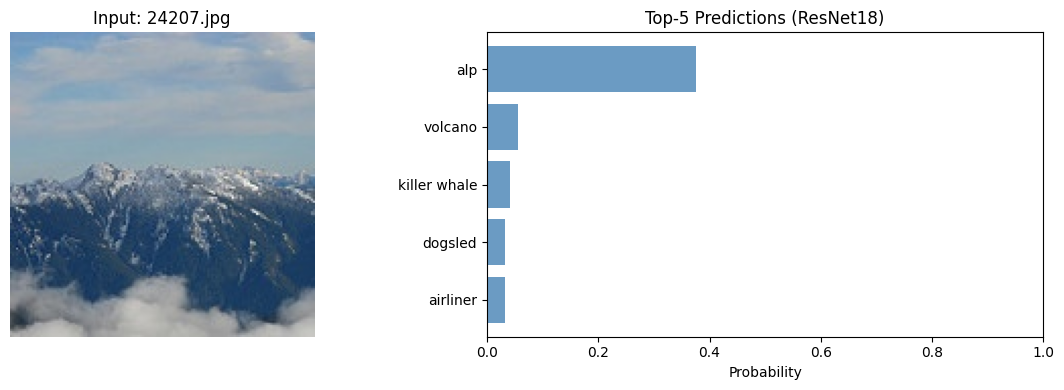

In [128]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Left panel: image
axes[0].imshow(img)
axes[0].axis("off")
axes[0].set_title(f"Input: {img_name}")

  # Right panel: horizontal bar chart
labels_plot = [p[0][:25] for p in preds]   # truncate long class names
probs_plot  = [p[1] for p in preds]

axes[1].barh(labels_plot[::-1], probs_plot[::-1], color="steelblue", alpha=0.8)
axes[1].set_xlabel("Probability")
axes[1].set_title("Top-5 Predictions (ResNet18)")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig("outputs/warmup_inference_viz.png", dpi=100)
plt.show()

  # For a non-technical dashboard: show the image + top-1 prediction + confidence bar.
  # A threshold of ~0.6 on top-1 probability is a reasonable starting point for
  # "confident enough to act on" — below that, route to a human reviewer.
  # The right threshold depends on the cost of a wrong automated decision.